# Практика 2

In [1]:
from abc import ABC, abstractmethod
from typing import Iterable, Callable, Iterator, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tqdm.auto as tqdm

plt.style.use("seaborn-v0_8-whitegrid")

### Базовый класс слоя

Для простоты реализации остальных классов создадим общий слой с нужным интерфейсом для модели. А именно:

1. Проход вперед - когда модель возвращает результат
2. Проход назад - когда модель возвращает градиенты и меняет веса
3. Скорость обучения

В данном случае изменение весов и скорость обучения интегрированы в класс, но в других пакетах и библиотеках это может быть по другому.

In [2]:
class Layer(ABC):
    @abstractmethod
    def forward(self, x: np.ndarray) -> np.ndarray:
        raise NotImplementedError

    @abstractmethod
    def backward(self, x: np.ndarray, grad: np.ndarray) -> np.ndarray:
        raise NotImplementedError

    @property
    def learning_rate(self):
        return self.__learning_rate

    @learning_rate.setter
    def learning_rate(self, value):
        self.__learning_rate = value

### Функции активации

Пойдем от простого. Реализуем функции активации и их простые градиенты (производные).

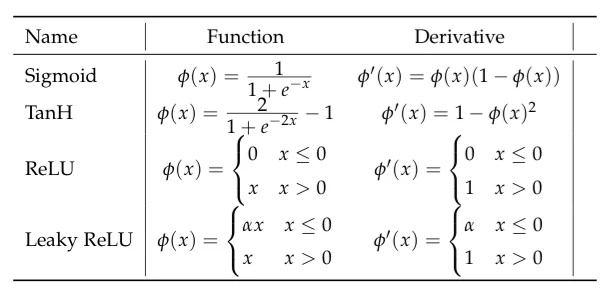

#### Сигомида

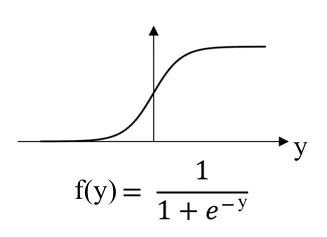

In [3]:
class Sigmoid(Layer):
    @staticmethod
    def sigmoid(x: np.ndarray) -> np.ndarray:
        return 1 / (1 + np.exp(-x))

    def forward(self, x):
        return self.sigmoid(x)

    def backward(self, x, grad):
        return grad * self.sigmoid(x) * (1 - self.sigmoid(x))

#### TanH

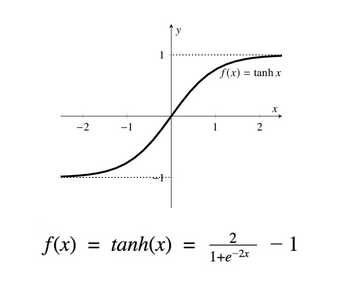

In [4]:
class TanH(Layer):
    @staticmethod
    def tanh(x: np.ndarray) -> np.ndarray:
        return 2 / (1 + np.exp(-2 * x)) - 1

    def forward(self, x):
        return self.tanh(x)

    def backward(self, x, grad):
        return grad * (1 - np.square(self.tanh(x)))

#### ReLU

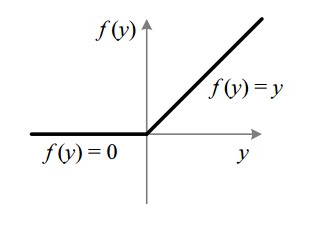

In [5]:
class ReLU(Layer):
    def forward(self, x):
        return np.where(x > 0, x, 0)

    def backward(self, x, grad):
        return grad * (x > 0)

#### LeakyReLU

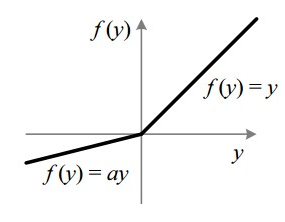

In [6]:
class LeakyReLU(Layer):
    def __init__(self, k: float = 0.01):
        self.k = k

    def forward(self, x):
        return np.where(x > 0, x, x * self.k)

    def backward(self, x, grad):
        return grad * np.where(x > 0, x > 0, self.k)

### Полносвязный слой

Данный класс сохраняет только веса и `learning_rate`, потому при обратном распространении требуется передавать полученные входные данные на момент прямого распротранения. Для инициализации весов (чтоб они не были нулями) используется нормальное распределение с ограничением в `sqrt(1/input_shape)`. Аналогичный способ инциализации использует библиотека Keras.

В `Dense.forward` входа перемножаются с весами и складываются со сдвигами (bias).
В `Dense.backward` градиент с прошлого слоя `grad` перемнажается с весами `self.weights.T`, тем самым мы получаем градиент входа `grad_x`, входы `x.T` перемноженные с градиентом `grad` возвращают градиент весов `grad_weights`, а среднее по градиенту это сдвиг `grad_biases`. Далее обратные градиенты умноженные на `learning_rate` изменяют веса.

#### P.S.

`@` - в `numpy` оператор собачки переопределен и работает как скалярное произведение векторов

In [20]:
class Dense(Layer):
    def __init__(self, input_shape: int, output_shape: int, learning_rate: float = 0.001):
        self.weights = np.random.normal(0.0, np.sqrt(1 / float(input_shape)), (input_shape,output_shape))
        self.biases = np.zeros(output_shape)
        self.learning_rate = learning_rate

    def forward(self, x):
        return x @ self.weights + self.biases

    def backward(self, x, grad):
        grad_x = grad @ self.weights.T

        grad_weights = x.T @ grad
        grad_biases = grad.mean(axis=0) * x.shape[0]

        self.weights = self.weights - self.learning_rate * grad_weights
        self.biases = self.biases - self.learning_rate * grad_biases

        return grad_x

### Функция ошибки

В данном примере воспользуется среднеквадратичной ошибкой. Если в функции указать `grad=True`, то будет вычислен градиент.

In [21]:
def mse_loss(y: np.ndarray, y_target: np.ndarray, grad: bool = False):
    diff = y - y_target
    if grad:
        return (2 / y.shape[0]) * diff
    squared_error = diff ** 2
    return np.mean(squared_error)

### Нейросеть

Класс нейросети очень прост, в него передается список слоев и функция ошибки. В функции `forward`, программа проходит по всем слоям и возвращает результаты всех активаций (данный список можно использовать в обучении или как в `predict` можно вернуть только последнее значение).

Для обучения сети сначала выполняем `forward` и сохраняем активации, при этом, для того чтоб учесть активации самого первого слоя, добавляем входные данные как первый элемент. Далее вычисляем грдиент ошибки и проходим в обратном порядке по слоям, передавая в каждый градиент предыдущего.

Результат обучения - средняя ошибка.

In [7]:
class NeuralNetwork:
    def __init__(self, layers: Iterable[Layer], loss_func: Callable):
        self.layers = layers
        self.loss_func = loss_func

    def forward(self, x: np.ndarray) -> np.ndarray:
        activation = x
        layer_activations = []
        for layer in self.layers:
            layer_activations.append(layer.forward(activation))
            activation = layer_activations[-1]
        return layer_activations

    def train(self, x: np.ndarray, y: np.ndarray):
        if y.ndim == 1:
            y = y[:, np.newaxis]

        layer_activations = self.forward(x)
        layer_inputs = [x] + layer_activations
        output = layer_activations[-1]

        grad = self.loss_func(output, y, True)
        for i, layer in reversed(list(enumerate(self.layers))):
            grad = layer.backward(layer_inputs[i], grad)

        return np.mean(self.loss_func(output, y, False))

    def predict(self, x: np.ndarray) -> np.ndarray:
        return self.forward(x)[-1]

### Батчинг

Слои - есть. Нейросеть - есть. Осталось обучить, но обучать сразу на всех данных не всегда правильно и удобно. Это связано с тем что градиенты и изменения весов могут занять слишком много памяти. Если разделить входные данные на части (батчи), то размеры градиентов будут меньше, а также меньше шума в данных, улучшается сходимость (нахождение минимума функции ошибки) и т.п.

In [8]:
def batches(x: np.ndarray,
            y: np.ndarray,
            batch_size: int,
            shuffle: bool = False) -> Iterator[Tuple[np.ndarray, np.ndarray]]:
    if shuffle:
        indices = np.random.permutation(len(x))
    for i in range(0, len(x) - batch_size + 1, batch_size):
        if shuffle:
            indices_slice = indices[i:i+batch_size]
            yield x[indices_slice], y[indices_slice]
        else:
            yield x[i:i+batch_size], y[i:i+batch_size]

#### Обучаем модельки

In [9]:
EPOCH_COUNT = 10
BATCH_SIZE = 64

INPUT_SIZE = 30
OUTPUT_SIZE = 1

In [10]:
def moving_average(a, n=30):
    ret = np.cumsum(a, dtype=float)
    ret[n:] = ret[n:] - ret[:-n]
    return ret[n - 1:] / n

def plot_batch_loss(batch_loss, n=30):
    plt.title("Batch loss")
    plt.plot(moving_average(batch_loss, n), label="Batch loss")
    plt.legend(loc="best")
    plt.show()

def plot_epoch_score(epoch_train_score, epoch_test_score):
    plt.title("Scores")
    plt.plot(epoch_train_score, label=f"Train (last={epoch_train_score[-1]:.2f})")
    plt.plot(epoch_test_score, label=f"Test (last={epoch_test_score[-1]:.2f})")
    plt.legend(loc="best")
    plt.show()

In [11]:
def train(n):
    losses = []
    r2s = ([], [])
    for epoch in tqdm.trange(EPOCH_COUNT):
        for batch_x, batch_y in batches(X_train, Y_train, BATCH_SIZE):
            losses.append(n.train(batch_x, batch_y))
        r2s[0].append(r2_score(Y_train, n.predict(X_train)))
        r2s[1].append(r2_score(Y_test, n.predict(X_test)))

    plot_batch_loss(losses, 30)
    plot_epoch_score(*r2s)

## Регрессия

In [12]:
from sklearn.datasets import make_regression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

#### Оценка регрессии

В данном примере воспользуемся R-squared или же [коэффициентом детерминации](https://ru.wikipedia.org/wiki/%D0%9A%D0%BE%D1%8D%D1%84%D1%84%D0%B8%D1%86%D0%B8%D0%B5%D0%BD%D1%82_%D0%B4%D0%B5%D1%82%D0%B5%D1%80%D0%BC%D0%B8%D0%BD%D0%B0%D1%86%D0%B8%D0%B8). Максимальное значение (наилучшее) равно 1. Это можно проверить сравнив реальные ответы самих с собой.

In [13]:
y = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])

In [14]:
print(f"Против случайных значений: {r2_score(y, np.random.uniform(1, 10, y.shape))}")

Против случайных значений: -0.923704627732395


In [15]:
print(f"Против себя: {r2_score(y, y)}")

Против себя: 1.0


In [16]:
print(f"Против похожего: {r2_score(y, np.array([0, 2, 2, 4, 5, 7, 7, 8, 9, 9]))}")

Против похожего: 0.9515151515151515


#### Линейная регрессия

Далее идет пример задачи, которую возможно не нужно решать с помощью нейросетей, потому что есть подходы попроще. Причиной этого является линейность. Нейросети справятся, однако они предназначены для других более сложных и нелинейных задач.

Форма X: (50, 1)
Форма y: (50,)


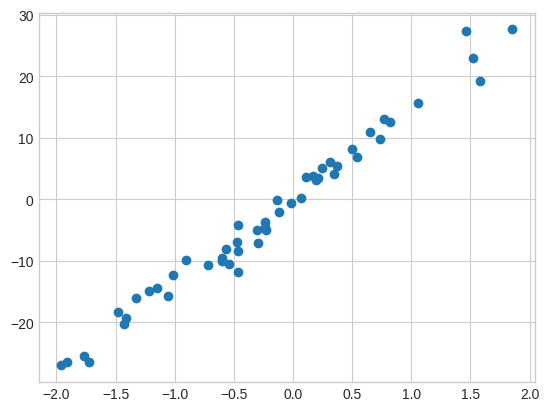

In [17]:
X, y = make_regression(n_samples=50, n_features=1, noise=2, random_state=42)

plt.scatter(X, y)

print("Форма X:", X.shape)
print("Форма y:", y.shape)

In [18]:
X, Y = make_regression(n_samples=50000, n_features=INPUT_SIZE, noise=15, random_state=42)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, train_size=0.8, random_state=42)

print("Форма X:", X.shape)
print("Форма y:", y.shape)

print("Форма X_train:", X_train.shape)
print("Форма Y_train:", Y_train.shape)
print("Форма X_test:", X_test.shape)
print("Форма Y_test:", Y_test.shape)

print("\nПример X_train:")
print(X_train[:1])

print("\nПример Y_train:")
print(Y_test[:1])

Форма X: (50000, 30)
Форма y: (50,)
Форма X_train: (40000, 30)
Форма Y_train: (40000,)
Форма X_test: (10000, 30)
Форма Y_test: (10000,)

Пример X_train:
[[-1.50946988e-01  5.02469938e-01 -2.24225334e-02  2.02067721e+00
   1.07818550e-01  1.25973000e+00  1.18093573e+00  4.68119186e-01
   4.62302947e-01 -1.00626486e+00  2.67182540e-01 -1.64131296e-03
  -2.84819347e-01  4.05442787e-01  8.28873641e-02  7.04691989e-02
   1.30909405e+00  1.36268582e+00  5.32515592e-01  9.50368252e-01
  -6.62386513e-01  7.55439917e-01 -1.29561650e+00  1.09861859e+00
   4.47109929e-01 -2.41885175e-01  1.73028240e+00  3.22143099e-01
  -5.06964725e-02  5.45201405e-01]]

Пример Y_train:
[-179.81171942]


Данная модель по сути и является типичным решением линейной регрессии. Подбираются веса для каждого входа и сдвиг. Подобным образом работает, например, [LinearRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html).

Отсюда и результат, модель идеально точно предсказывает значения регрессии.

  0%|          | 0/10 [00:00<?, ?it/s]

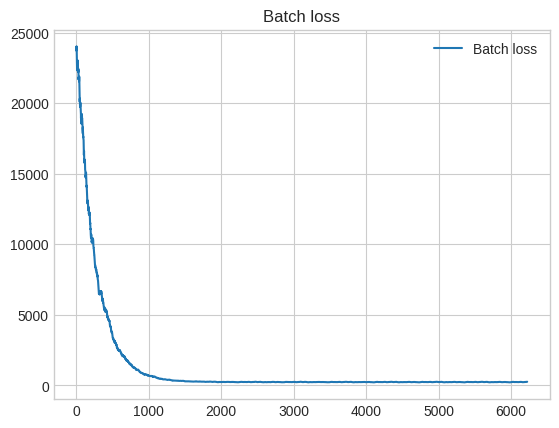

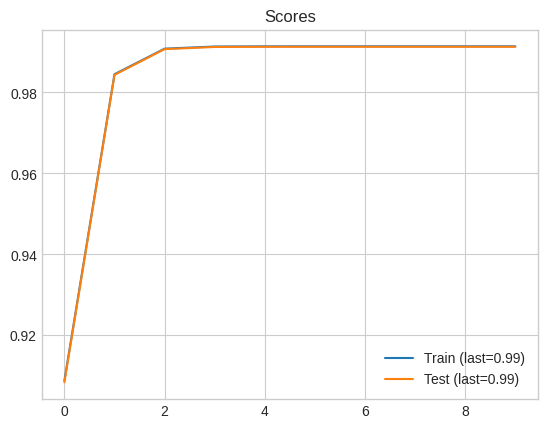

In [22]:
n = NeuralNetwork((
    Dense(INPUT_SIZE, OUTPUT_SIZE),
), loss_func=mse_loss)

train(n)

#### Наша задача

Попробуем добавить нелинейности, далее описана функция создающая полиномиальную регрессию.

In [23]:
def make_polynomial_regression(n_samples=100, n_features=1, degree=2, noise=0.0,
                               feature_range=(-5, 5), target_scale=1.0,
                               coeff_distribution="uniform", random_state=None):
    if random_state is not None:
        np.random.seed(random_state)

    X_base = np.random.uniform(low=feature_range[0], high=feature_range[1], size=(n_samples, 1))
    X = np.hstack([X_base, np.random.uniform(low=feature_range[0], high=feature_range[1], size=(n_samples, n_features - 1))])

    y_polynomial = np.zeros(n_samples)

    if coeff_distribution == 'uniform':
        poly_coeffs = np.random.uniform(low=-3.0, high=3.0, size=degree + 1) * target_scale
        poly_coeffs[0] = np.random.uniform(low=-1.0, high=1.0) * target_scale
        if degree > 1:
            for i in range(2, degree + 1):
                 poly_coeffs[i] /= (i ** 1.5)
    elif coeff_distribution == 'random_walk':
        steps = np.random.normal(loc=0, scale=1.0, size=degree + 1)
        poly_coeffs = np.cumsum(steps) * target_scale
        poly_coeffs[0] *= 0.5
        if np.max(np.abs(poly_coeffs)) > 0:
            poly_coeffs /= np.max(np.abs(poly_coeffs)) * 2
            poly_coeffs *= target_scale

    for i in range(n_samples):
        x_val = X_base[i, 0]
        term = 0
        for j in range(degree + 1):
            term += poly_coeffs[j] * (x_val ** j)
        y_polynomial[i] = term

    if noise > 0.0:
        noise_values = np.random.normal(loc=0.0, scale=noise, size=n_samples)
        y = y_polynomial + noise_values
    else:
        y = y_polynomial

    return X, y

Из графика видно, что линейность пропала и при попытке воспользоваться линейной регрессией мы будет получает большие ошибки.

Форма X: (50, 1)
Форма y: (50,)


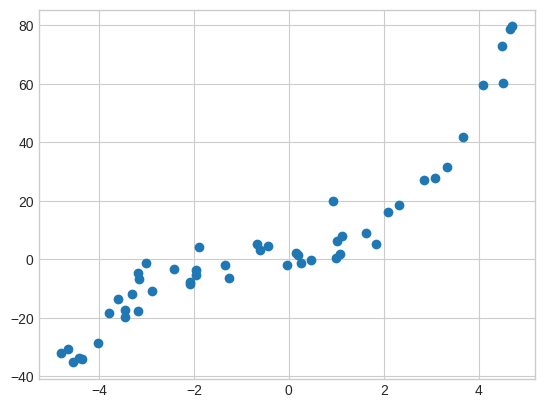

In [24]:
X, y = make_polynomial_regression(n_samples=50, n_features=1, degree=3, noise=5, random_state=42)

plt.scatter(X, y)

print("Форма X:", X.shape)
print("Форма y:", y.shape)

In [25]:
X, Y = make_polynomial_regression(n_samples=50000, n_features=INPUT_SIZE, noise=5, random_state=42)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, train_size=0.8, random_state=42)

print("Форма X:", X.shape)
print("Форма y:", y.shape)

print("Форма X_train:", X_train.shape)
print("Форма Y_train:", Y_train.shape)
print("Форма X_test:", X_test.shape)
print("Форма Y_test:", Y_test.shape)

print("\nПример X_train:")
print(X_train[:1])

print("\nПример Y_train:")
print(Y_test[:1])

Форма X: (50000, 30)
Форма y: (50,)
Форма X_train: (40000, 30)
Форма Y_train: (40000,)
Форма X_test: (10000, 30)
Форма Y_test: (10000,)

Пример X_train:
[[-0.7201764  -2.20694483 -3.06432036  1.16238565 -4.55011975  3.11143956
  -4.29636134 -3.86600837  2.94007314 -3.10941199  2.17682672 -3.3246918
   4.62930608 -4.24369147 -2.08972039  2.40319975  0.15190989 -4.30504331
   3.7208093   1.07679804  2.34783318  1.08668728 -1.01479106  2.66797888
  -1.11679615 -2.32759819  3.20715254  3.01283381  2.3651422   3.30431029]]

Пример Y_train:
[2.78148242]


Ну и очевидно, модель, подходящая для линейной задачи, больше не работает. Она просто не может научится так как все время получает большие ошибки.

  0%|          | 0/10 [00:00<?, ?it/s]

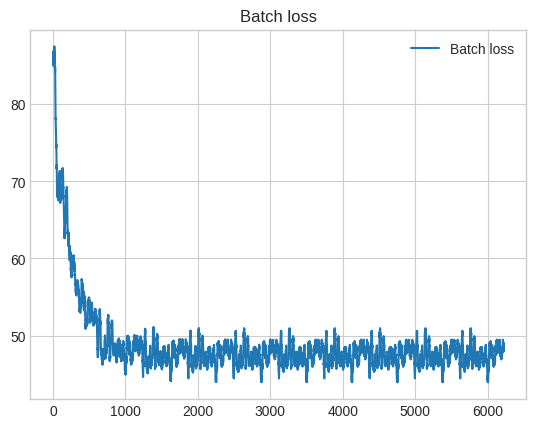

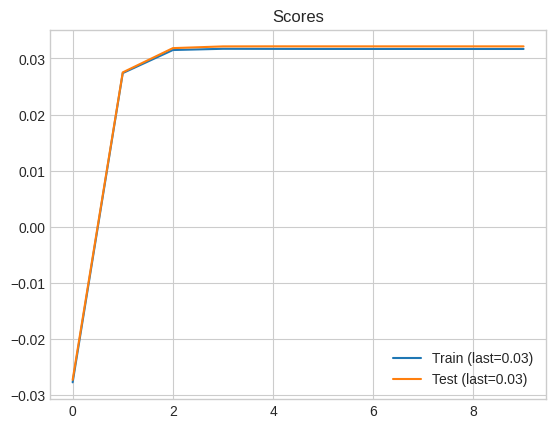

In [26]:
n = NeuralNetwork((
    Dense(INPUT_SIZE, OUTPUT_SIZE),
), loss_func=mse_loss)

train(n)

А что если добавить еще слой? И в целом это может сработать для данных где мало шума. Но все равно трудно избавится от линейности из-за линейных преобразований данных. А еще есть небольшие проблемы связанные с градиентами и их значениями. В некоторые моменты градиенты могут быть слишком большими и просто сломать модель.

  0%|          | 0/10 [00:00<?, ?it/s]

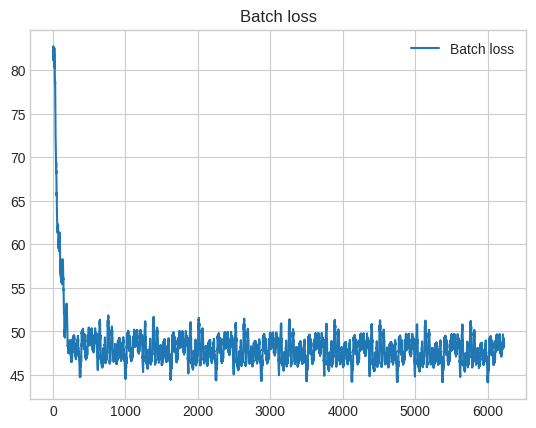

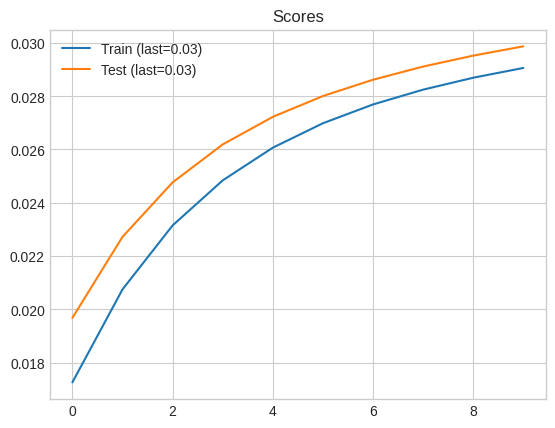

In [27]:
n = NeuralNetwork((
    Dense(INPUT_SIZE, 15),
    Dense(15, OUTPUT_SIZE),
), loss_func=mse_loss)

train(n)

Здесь на помощь приходят функции активации, которые добавят нелинейности. Результат говорит сам за себя.

  0%|          | 0/10 [00:00<?, ?it/s]

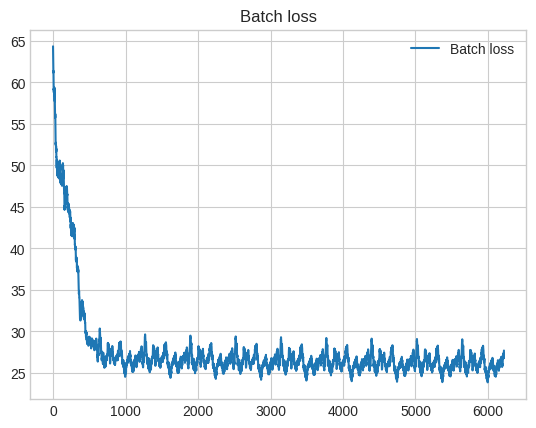

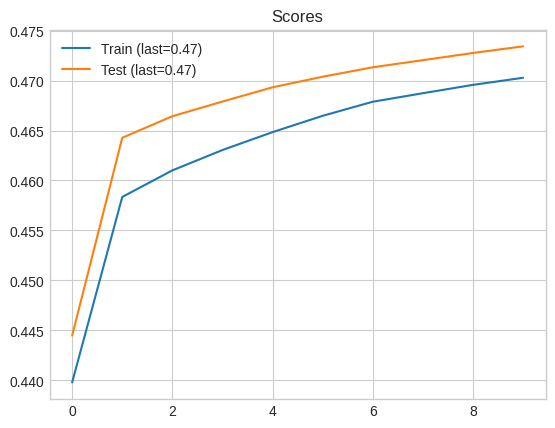

In [28]:
n = NeuralNetwork((
    Dense(INPUT_SIZE, 15),
    ReLU(),
    Dense(15, OUTPUT_SIZE),
), loss_func=mse_loss)

train(n)

Однако далеко не все функции активации работают. Например, сигмоида, при всех равных не сильно справляется с задачей.

  0%|          | 0/10 [00:00<?, ?it/s]

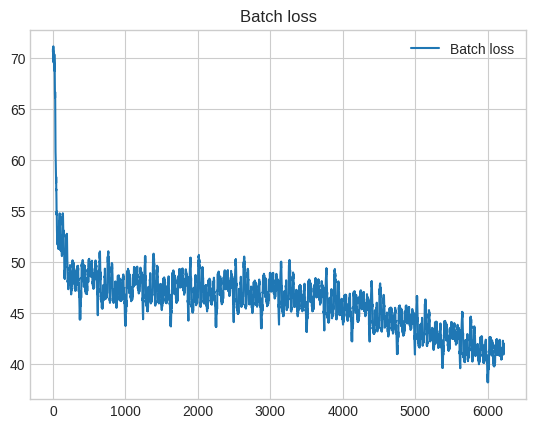

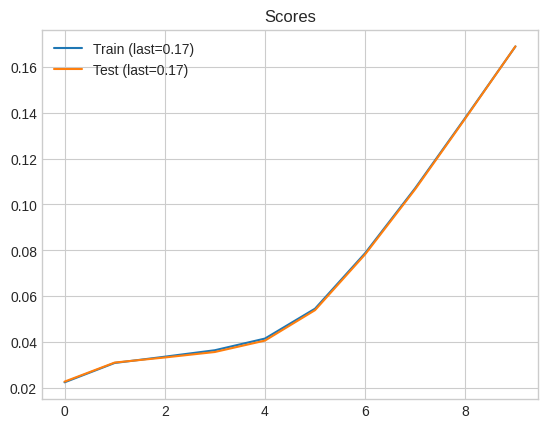

In [29]:
n = NeuralNetwork((
    Dense(INPUT_SIZE, 15),
    Sigmoid(),
    Dense(15, OUTPUT_SIZE),
), loss_func=mse_loss)

train(n)

И особенно функции активации не справляется если их неправильно использовать.

В примере ниже модели уже ничего не поможет. Проблема в том что выходные значения модели будут всегда равны между 0 и 1, а у задачи это явно не так.

Однако это не значит что активационные функции нельзя использовать в конце. Просто это зависит от задачи, например, если задача предсказать бинарное значение, то почему бы не использовать сигмоиду.  

In [ ]:
list(map(lambda x: round(float(x), 2), Sigmoid.sigmoid(np.array([-100, -10, -1, -0.5, -0.25, 0, 0.25, 0.5, 1, 10, 100]))))

[0.0, 0.0, 0.27, 0.38, 0.44, 0.5, 0.56, 0.62, 0.73, 1.0, 1.0]

In [ ]:
float(min(Y_test)), float(np.mean(Y_test)), float(max(Y_test))

(-35.833344766601115, -6.0637504713797865, 16.411457116808947)

  0%|          | 0/10 [00:00<?, ?it/s]

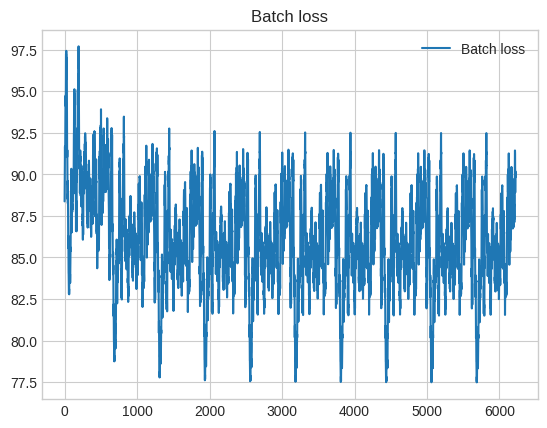

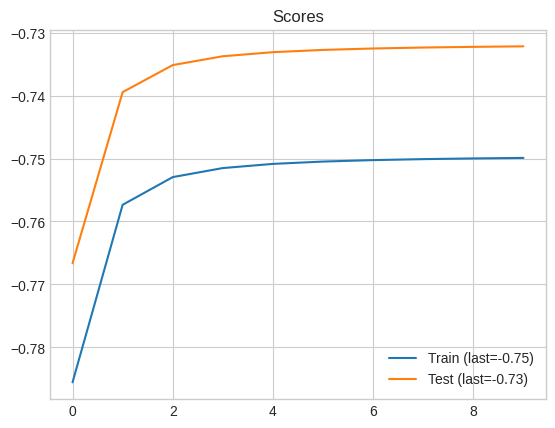

In [30]:
n = NeuralNetwork((
    Dense(INPUT_SIZE, 15),
    Dense(15, OUTPUT_SIZE),
    Sigmoid(),
), loss_func=mse_loss)

train(n)

Далее - эксперименты, возможно другие виды слоев, их комбинации и т.п. сработают лучше чем просто линейные.

Но не стоит забывать, что не всегда тяжелая и глубокая модель хороша - они дольше учаться, сложнее учаться и могут спокойно уступать по качеству меньшим собратьям.

  0%|          | 0/10 [00:00<?, ?it/s]

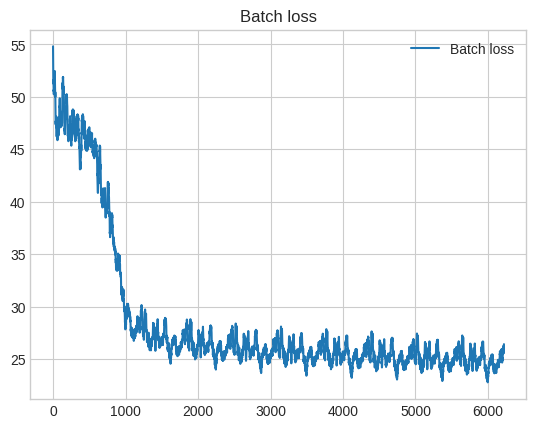

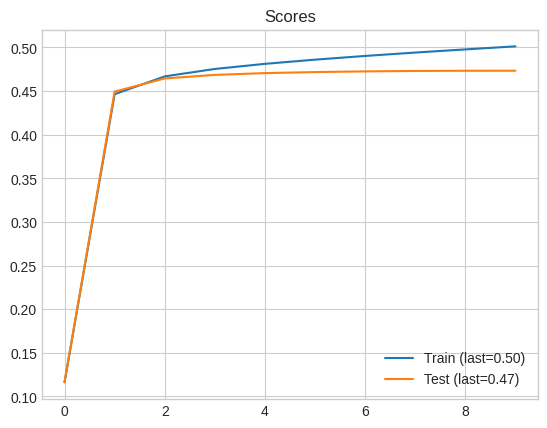

In [31]:
n = NeuralNetwork((
    Dense(INPUT_SIZE, 128),
    LeakyReLU(),
    Dense(128, 512),
    ReLU(),
    Dense(512, 128),
    Sigmoid(),
    Dense(128, OUTPUT_SIZE),
), loss_func=mse_loss)

train(n)